# Digit recognizer
Programa creado para clasificar imágenes 28x28 de dígitos según su etiqueta 0-9 con algoritmos de Inteligencia Artificial

### IDEAS
- Darle pesos (con ML?) a cada imagen del dataset en la creación de los números ideales, ya que no todas son igual de representativas
- Probar con redes neuronales (NNs)

# Análisis del dataset

In [1]:
"""
IMPORTANTE:
En Github no se encuentran los archivos de 'train.csv' y 'test.csv' (pesan mucho)
Sin embargo, si que tenemos una carpeta ZIP con esos archivos. Para ejecutar el código,
se deben extraer primero (dentro de la carpeta)
"""

import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [2]:
# train.describe()

In [3]:
# Para reducir los tiempos de espera, se reduce el dataframe de train
train = train[:5_000]

In [4]:
train_nulls = train.isnull().sum().values
test_nulls = test.isnull().sum().values

print(f"Número de valores nulos en train: {train_nulls.sum()}")
print(f"Número de valores nulos en test: {test_nulls.sum()}")

Número de valores nulos en train: 0
Número de valores nulos en test: 0


Vemos en la documentación (https://www.kaggle.com/competitions/digit-recognizer) que las imágenes tienen 28x28 píxeles en escala de grises, con valores entre 0-255

Primero, vamos a normalizar las columnas para que tengan valores entre 0 y 1. Luego, crearçmos una función que muestre por pantalla una imagen específica del dataset para visualizarla mejor

In [5]:
# Dividimos cada columna entre 255
for col in train.columns:
    if col != "label":
        train[col] /= 255

for col in test.columns:
    if col != "label":
        test[col] /= 255

# Comprobamos que haya funcionado
# train.describe()

In [6]:
# Como parece que vamos a usar mucho este código, añado una función que convierta una fila de los datos en un array 2D
def crearMatriz(df, i):
    img = df.iloc[i]

    # Quitamos la columna 'label' si existe
    title = f"Image #{i}"
    label = None
    if "label" in img.index:
        title += f" (Number {int(img["label"])})"
        label = int(img["label"])
        # Convertimos el data series de pandas a un array de numpy
        # y eliminamos el valor "label" (ubicado en la primera posición)
        img = img.values[1:]
    else:
        img = img.values
        

    # Ahora, transformamos el array en un array 2D, 28x28
    img = img.reshape((28, 28))
    
    return img, label, title

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def mostrarImagen(df, i):
    """
    df: dataframe
    i: integer
    """
    img, label, title = crearMatriz(df, i)

    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(label=title)
    plt.show()

# mostrarImagen(train, 42)

Creamos una función para visualizar todos los datos de un dataset [simplemente para probar que números aparecen]

In [8]:
from IPython.display import clear_output


def mostrarImgsDataframe(df, inicio, fin):
    # Activa modo interactivo
    plt.ion()

    for i in range(inicio, fin):
        # Usamos el código anterior para dibujar la matriz 2D
        img, label, title = crearMatriz(df, i)

        plt.imshow(img, cmap="gray", vmin=0, vmax=1)
        plt.title(label=title)
        plt.axis("off")

        # Refrescamos la ventana y esperamos N segundos
        plt.pause(0.02)

        # Borramos el output anterior
        clear_output(wait=True)
        plt.show()


# mostrarImgsDataframe(train, 0, 10)

# Creación de las matrices de 'números ideales'

Con el fin de evaluar a que label corresponde cada matriz, vamos a comprobar a que 'número ideal' se parece más dicha matriz. Estos 'números ideales' serán calculados como la media de los números de ese 'label'; es decir, se superponen los números uno encima de otro y se calcula cual es el 'número promedio' o 'número ideal'

In [9]:
# Función para mostrar las imágenes de esos números ideales. La usaremos más adelante
def mostrarNumsIdeales(nums, figsize=(7, 7)):
    """
    nums: list de números ideales
    """

    fig, axs = plt.subplots(nrows=2, ncols=5, figsize=figsize)
    # Convertimos la matriz 2D de sublots en una lista 1D
    axs = axs.flatten()

    for i in range(len(nums)):
        img = nums[i]
        title = f"Número {i}"

        axs[i].set_title(title)
        axs[i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axs[i].axis("off")

    plt.show()

In [10]:
# --- Para el conjunto 'train', se crea un número ideal para cada label 0-9 ---
# print("=" * 70)
# print("="*20, "SOLO ALGUNAS MUESTRAS", "="*20)
# print("=" * 70)

# Creamos unas matrices para guardar la suma/superposición de matrices
nums_ideales = []
for i in range(10):
    matriz = np.zeros((28, 28))
    nums_ideales.append(matriz)

# VALOR HARD-CODEADO
# for i in range(30):
for i in range(len(train)):
    img, label, _ = crearMatriz(train, i)

    # Sumamos los valores de cada pixel a su matriz correspondiente
    nums_ideales[label] += img

media_total_pixeles = 0

# Ahora, necesitamos normalizar los valores entre 0 y 1
for i in range(len(nums_ideales)):
    valor_maximo = nums_ideales[i].max()
    if valor_maximo == 0:
        raise ValueError("La matriz está vacía")

    # El valor máximo tendrá un valor de (1 / valor_maximo) * valor_maximo = 1
    # Y el mínimo de (1 / valor_maximo) * 0 = 0
    nums_ideales[i] = np.multiply(1 / valor_maximo, nums_ideales[i])

    # -- Suavizamos la nube borrosa incluyendo solo los datos por encima de un valor límite --
    limite = 0.5
    # Coeficiente de suavizado (0 elimina el píxel, 1 no hace ningún cambio)
    coef_suavizado = 0.75

    # for x in range(nums_ideales[i].shape[0]):
    #     for y in range(nums_ideales[i].shape[1]):
    #         # Si es menor que el límite, suavizamos su valor
    #         if nums_ideales[i][x][y] < limite:
    #             nums_ideales[i][x][y] *= coef_suavizado
    media_total_pixeles += nums_ideales[i].sum()

# media_total_pixeles /= len(nums_ideales)
# print("media", media_total_pixeles)
# # -- Queremos que todas las matrices tengan la misma cantidad de pixeles blancos --
# # La suma de todos los pixeles debe ser 'media_total_pixeles', por lo que debemos dividir cada
# # pixel por la diferencia (sum() / media_total_pixeles)
# for i in range(len(nums_ideales)):
#     suma = nums_ideales[i].sum()
#     factor_mult = media_total_pixeles / suma
#     nums_ideales[i] *= factor_mult

# # Comprobamos
# for i in range(len(nums_ideales)):
#     suma = nums_ideales[i].sum()
#     print(i, suma)

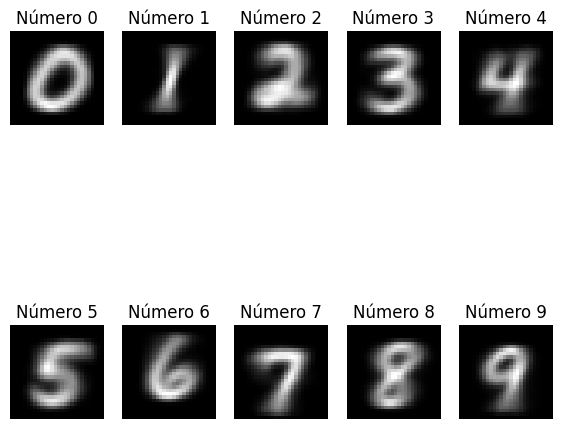

In [11]:
# Podemos visualizar el resultado usando las funciones anteriores
mostrarNumsIdeales(nums_ideales)

### Comparación de los datos y los números ideales

Ahora, podemos ver si somos capaces de identificar una imagen por su similitud a un número ideal

Para ello, compararemos esa imagen con cada número ideal y elegimos la que sea más parecida (la que tenga menor error)

In [12]:
# def predict(df, j, mostrarErrores = True, mostrarImg=False):
#     img, label, title = crearMatriz(df, j)

#     # Guardamos la matriz de error de cada número ideal
#     matrices_resta = []

#     for i in range(len(nums_ideales)):
#         resta = np.abs(np.subtract(nums_ideales[i], img))

#         # Normalizamos el resultado entre 0 y 1
#         valor_maximo = resta.max()
#         resta = np.multiply(1 / valor_maximo, resta)

#         matrices_resta.append(resta)

#     # Calculamos la matriz error más 'oscura' (la que tiene una suma de pixeles más baja)
#     # La matriz que más a cambiado (la que comparte más pixeles)
#     errors = []
#     for i in range(len(nums_ideales)):
#         err = np.subtract(nums_ideales[i], matrices_resta[i])
#         err = err.sum()
#         errors.append(err)

#     num_pixeles = img.shape[0] * img.shape[1]
#     min_err = min(errors) / num_pixeles
#     min_err_index = errors.index(min(errors))
#     print(f"Mínimo error: {min_err}")
#     print(f"Predicción: {min_err_index}")

#     if mostrarImg:
#         mostrarImagen(df, j)
#     if mostrarErrores:
#         mostrarNumsIdeales(matrices_resta, figsize=(7, 5))
#         diferencias = []
#         for i in range(len(nums_ideales)):
#             diferencias.append(np.subtract(nums_ideales[i], matrices_resta[i]))
#         mostrarNumsIdeales(diferencias, figsize=(7, 5))

#     # Devolvemos el valor del mínimo error; es decir, el índice de la matriz correspondiente
#     return min_err_index    

# predict(train, 42)
# predict(train, 5)
# predict(train, 7)

Errores: [67.588, -36.957, 69.009, 40.851, 16.123, 47.113, 29.938, 17.378, 43.23, 16.587]	Mínimo err: -36.957
Probabilidades: [0.217, -0.119, 0.222, 0.131, 0.052, 0.152, 0.096, 0.056, 0.139, 0.053] ----> 2


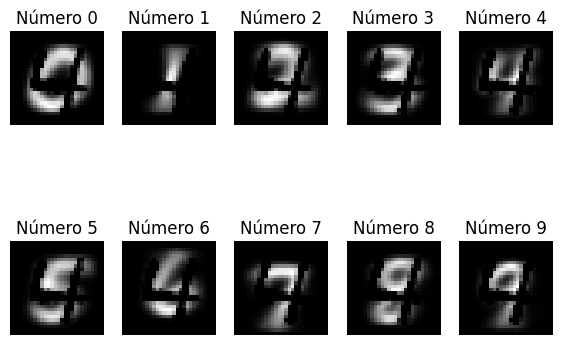

Errores: [83.953, -28.482, 75.325, 49.325, 23.862, 55.588, 38.964, 26.595, 51.544, 25.685]	Mínimo err: -28.482
Probabilidades: [0.209, -0.071, 0.187, 0.123, 0.059, 0.138, 0.097, 0.066, 0.128, 0.064] ----> 0


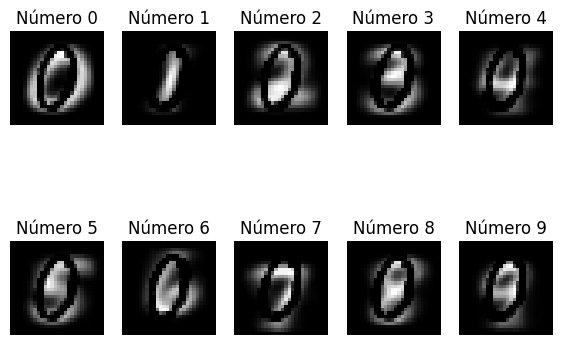

Errores: [71.251, -34.939, 70.513, 49.597, 19.014, 54.654, 33.601, 21.041, 46.965, 19.74]	Mínimo err: -34.939
Probabilidades: [0.203, -0.099, 0.201, 0.141, 0.054, 0.156, 0.096, 0.06, 0.134, 0.056] ----> 0


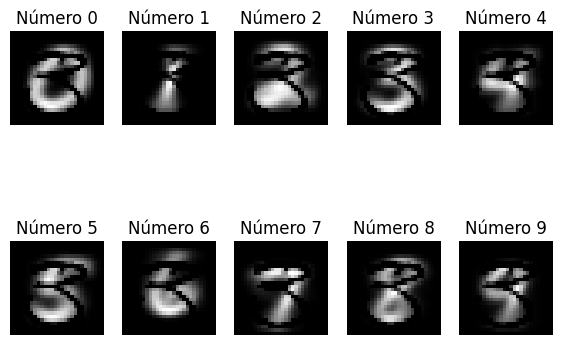

0

In [13]:
def predict(df, j, mostrarErrores=True, mostrarImg=False):
    img, label, title = crearMatriz(df, j)

    # Guardamos la matriz de error de cada número ideal
    matrices_resta = []
    errores = []

    for i in range(len(nums_ideales)):
        err = np.abs(np.subtract(nums_ideales[i], img))
        err = np.multiply(nums_ideales[i], img)
        inversa = np.ones_like(nums_ideales[i]) - img
        err = nums_ideales[i] - inversa
        err = nums_ideales[i] - img  # Mejor la que tenga menor suma

        # Normalizamos el resultado entre 0 y 1
        valor_maximo = err.max()
        err = np.multiply(1 / valor_maximo, err)

        mse = np.mean((nums_ideales[i] - img) ** 2)
        mse = err.sum()  # Mejor la que tenga menor suma

        matrices_resta.append(err)
        errores.append(float(round(mse, 3)))

    # Normalizamos los errores para conseguir la probabilidad
    vector_probabilidades = []
    for i in range(len(errores)):
        probabilidad = float(errores[i] / sum(errores))
        vector_probabilidades.append(round(probabilidad, 3))

    num_pixeles = img.shape[0] * img.shape[1]
    min_err = min(errores)

    prediction = vector_probabilidades.index(max(vector_probabilidades))
    print(f"Errores: {errores}\tMínimo err: {min_err}")
    print(f"Probabilidades: {vector_probabilidades} ----> {prediction}")

    if mostrarImg:
        mostrarImagen(df, j)
    if mostrarErrores:
        mostrarNumsIdeales(matrices_resta, figsize=(7, 5))
        diferencias = []
        for i in range(len(nums_ideales)):
            diferencias.append(np.subtract(nums_ideales[i], matrices_resta[i]))
        # mostrarNumsIdeales(diferencias, figsize=(7, 5))

    # Devolvemos el valor del mínimo error; es decir, el índice de la matriz correspondiente
    return prediction


predict(train, 42)
predict(train, 5)
predict(train, 7)